In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings("ignore")

In [27]:
df = pd.read_excel('data/serie_cafe_cepea_mensal.xlsx')
df.rename(columns = {
    'Data': 'date',
    'À vista R$': 'price_brl',
    'À vista US$': 'price_usd'
}, inplace = True)
df["log_price_brl"] = np.log(df["price_brl"])

In [28]:
# Criação de features lagadas

def create_lagged_dataframe(series, n_lags=6):
    df_lag = pd.DataFrame(series)
    for i in range(1, n_lags + 1):
        df_lag[f'lag_{i}'] = df_lag.iloc[:, 0].shift(i)
    df_lag.dropna(inplace=True)
    return df_lag

In [29]:
def walk_forward_forecast(
    series,
    model_func,
    start_train_idx,
    horizon
):
    """
    series: pandas Series (log-price mensal)
    model_func: função que recebe série de treino e horizonte e retorna previsão
    start_train_idx: índice inicial do walk-forward
    horizon: horizonte de previsão (int)
    """
    
    forecasts = []
    actuals = []
    dates = []

    for t in range(start_train_idx, len(series) - horizon):
        train = series.iloc[:t]
        test = series.iloc[t + horizon]

        y_hat = model_func(train, horizon)

        forecasts.append(y_hat)
        actuals.append(test)
        dates.append(series.index[t + horizon])

    return pd.DataFrame({
        "date": dates,
        "y_true": actuals,
        "y_pred": forecasts
    }).set_index("date")


def forecast_metrics(df):
    rmse = np.sqrt(np.mean((df.y_true - df.y_pred) ** 2))
    mae = np.mean(np.abs(df.y_true - df.y_pred))
    mape = np.mean(np.abs((df.y_true - df.y_pred) / df.y_true)) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

In [30]:
from sklearn.ensemble import RandomForestRegressor

def rf_model(train_series, horizon, n_lags=12):

    df_lag = create_lagged_dataframe(train_series, n_lags)

    X = df_lag.drop(columns="log_price_brl")
    y = df_lag["log_price_brl"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X, y)

    last_window = train_series.iloc[-n_lags:].values[::-1]

    X_pred = last_window.reshape(1, -1)

    for _ in range(horizon):
        y_hat = model.predict(X_pred)[0]
        X_pred = np.roll(X_pred, 1)
        X_pred[0, 0] = y_hat

    return y_hat

def xgboost_model(train_series, horizon, n_lags=12):

    df_lag = create_lagged_dataframe(train_series, n_lags)

    X = df_lag.drop(columns="log_price_brl")
    y = df_lag["log_price_brl"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X, y)

    last_window = train_series.iloc[-n_lags:].values[::-1]

    X_pred = last_window.reshape(1, -1)

    for _ in range(horizon):
        y_hat = model.predict(X_pred)[0]
        X_pred = np.roll(X_pred, 1)
        X_pred[0, 0] = y_hat

    return y_hat

In [31]:
from xgboost import XGBRegressor


def xgb_model(train_series, horizon, n_lags=12):

    df_lag = create_lagged_dataframe(train_series, n_lags)

    X = df_lag.drop(columns="log_price_brl")
    y = df_lag["log_price_brl"]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    )

    model.fit(X, y)

    last_window = train_series.iloc[-n_lags:].values[::-1]
    X_pred = last_window.reshape(1, -1)

    for _ in range(horizon):
        y_hat = model.predict(X_pred)[0]
        X_pred = np.roll(X_pred, 1)
        X_pred[0, 0] = y_hat

    return y_hat

In [32]:
series = df.set_index("date")["log_price_brl"]

start_train_idx = series.index.get_loc("2018-01-01")

for h in [1, 3, 6]:

    print(f"\nRodando Random Forest – horizonte {h} mês(es)")

    results_rf = walk_forward_forecast(
        series,
        rf_model,
        start_train_idx,
        horizon=h
    )

    print(forecast_metrics(results_rf))


Rodando Random Forest – horizonte 1 mês(es)
{'RMSE': 0.15505310249806542, 'MAE': 0.11925221451430035, 'MAPE': 1.7259143023615622}

Rodando Random Forest – horizonte 3 mês(es)
{'RMSE': 0.23010493366884704, 'MAE': 0.17496441241994654, 'MAPE': 2.5089552296792723}

Rodando Random Forest – horizonte 6 mês(es)
{'RMSE': 0.3173866645608175, 'MAE': 0.24951688261303326, 'MAPE': 3.5568262784960427}


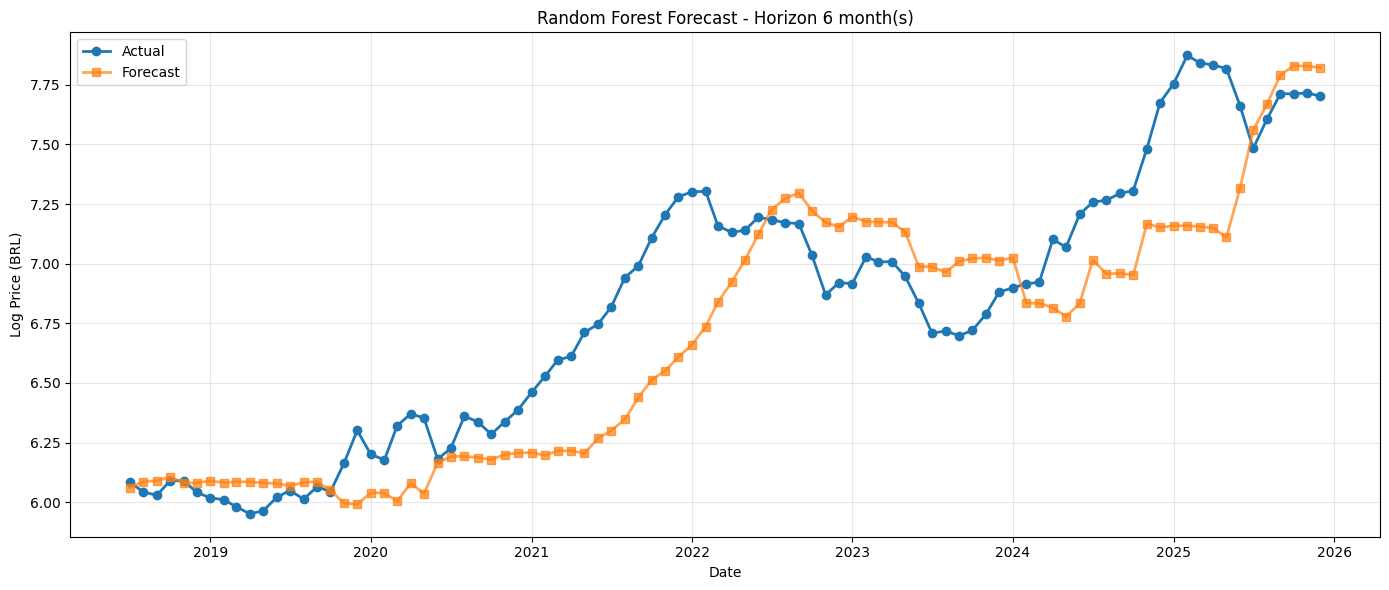

In [33]:
plt.figure(figsize=(14, 6))
plt.plot(results_rf.index, results_rf['y_true'], label='Actual', marker='o', linewidth=2)
plt.plot(results_rf.index, results_rf['y_pred'], label='Forecast', marker='s', linewidth=2, alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Log Price (BRL)')
plt.title(f'Random Forest Forecast - Horizon {h} month(s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
series = df.set_index("date")["log_price_brl"]

for h in [1, 3, 6]:

    print(f"\nRodando XGBoost – horizonte {h} mês(es)")

    results_xgb = walk_forward_forecast(
        series,
        xgb_model,
        start_train_idx,
        horizon=h
    )

    print(forecast_metrics(results_xgb))


Rodando XGBoost – horizonte 1 mês(es)
{'RMSE': 0.15272294836770756, 'MAE': 0.11753100000859745, 'MAPE': 1.7101143604963613}

Rodando XGBoost – horizonte 3 mês(es)
{'RMSE': 0.22469972742569522, 'MAE': 0.16643323784161504, 'MAPE': 2.3904783757270636}

Rodando XGBoost – horizonte 6 mês(es)
{'RMSE': 0.3236943317022753, 'MAE': 0.24475604643177976, 'MAPE': 3.515384066681527}
